<a href="https://colab.research.google.com/github/keerthanamjohn3-arch/git.demo/blob/main/LoanApproval_dataset_NaiveBayesClassifier_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Datasets/LoanApprovalPrediction.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
df['Married'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
# df["Gender"] = df["Gender"].fillna(df["Gender"].mod()[0])
# df["Married"] = df["Married"].fillna(df["Married"].mod()[0])
# df["Dependents"] = df["Dependents"].fillna(df["Dependemnts"].mod()[0])
# df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mean())
# df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mod()[0])
# df["LoanAmount_Term"] = df["LoanAmount_Term"].fillna(df["LoanAmount_Term"].mod()[0])
# df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mod()[0])
# df

In [ ]:
loan_cols=['Gender','Married','Dependents','Self_Employed','Loan_Amount_Term','Credit_History']
for col in loan_cols:
  df[col]=df[col].fillna(df[col].mode()[0])

In [ ]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mean())

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
cat_colms = df.select_dtypes(include = 'O').columns
cat_colms

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
categ_cols = ['Gender','Married','Dependents','Education',
       'Self_Employed', 'Property_Area', 'Loan_Status']
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in categ_cols:
  df[col]=encoder.fit_transform(df[col])
df



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,0,0,2900,0.0,71.000000,360.0,1.0,0,1
610,LP002979,1,1,3,0,0,4106,0.0,40.000000,180.0,1.0,0,1
611,LP002983,1,1,1,0,0,8072,240.0,253.000000,360.0,1.0,2,1
612,LP002984,1,1,2,0,0,7583,0.0,187.000000,360.0,1.0,2,1


In [ ]:
X = df.iloc[:,1:-1]
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.000000,360.0,1.0,0
610,1,1,3,0,0,4106,0.0,40.000000,180.0,1.0,0
611,1,1,1,0,0,8072,240.0,253.000000,360.0,1.0,2
612,1,1,2,0,0,7583,0.0,187.000000,360.0,1.0,2


In [ ]:
y = df.iloc[:,-1]
y

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
Scaler = MinMaxScaler()
Scaler.fit(X)
X_scaled = Scaler.transform(X)
#X_scaled = scaler.fit_transform(X)
X_scaled

array([[1.        , 0.        , 0.        , ..., 0.74358974, 1.        ,
        1.        ],
       [1.        , 1.        , 0.33333333, ..., 0.74358974, 1.        ,
        0.        ],
       [1.        , 1.        , 0.        , ..., 0.74358974, 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 0.33333333, ..., 0.74358974, 1.        ,
        1.        ],
       [1.        , 1.        , 0.66666667, ..., 0.74358974, 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , ..., 0.74358974, 0.        ,
        0.5       ]])

In [ ]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size = 0.3,random_state =3)

In [ ]:
X_train.shape,y_train.shape

((429, 11), (429,))

In [ ]:
X_test.shape,y_test.shape

((185, 11), (185,))

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
nb = GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred = nb.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1])

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred)*100)

84.86486486486487


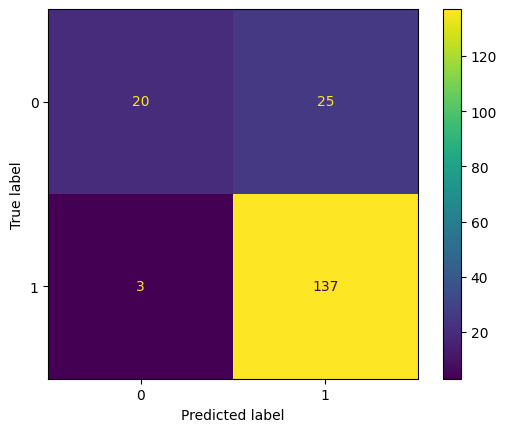

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,digits = 4))

              precision    recall  f1-score   support

           0     0.8696    0.4444    0.5882        45
           1     0.8457    0.9786    0.9073       140

    accuracy                         0.8486       185
   macro avg     0.8576    0.7115    0.7478       185
weighted avg     0.8515    0.8486    0.8297       185



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train,y_train)
y_pred1 = knn.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.44      0.59        45
           1       0.85      0.98      0.91       140

    accuracy                           0.85       185
   macro avg       0.86      0.71      0.75       185
weighted avg       0.85      0.85      0.83       185



# **Handling Imbalanced Dataset**


here majority class - 1'
     minority class - 0

1.Oversampling ------->Increase no.of values in minority class
    # 1- 422
    # 0->422
2.UnderSampling------->Decrease the no.of values in the mojority class
    #1-192
    #0->192

    #Synthetic Minority Over Sampling Technique(SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state = 1)
X_os,y_os = os.fit_resample(X,y)
y_os.value_counts()

,count
Loan_Status,
1,422
0,422


In [ ]:
# scaler = MinMaxScaler()
X_os_scaled = Scaler.fit_transform(X_os)

In [ ]:
X_train_os,X_test_os,y_train_os,y_test_os = train_test_split(X_os,y_os,test_size = 0.3,random_state = 3)

In [ ]:
X_train_os.shape,y_train_os.shape

((590, 11), (590,))

In [ ]:
X_test_os.shape,y_train_os.shape

((254, 11), (590,))

In [ ]:
nb.fit(X_train_os,y_train_os)
y_pred = nb.predict(X_test_os)
y_pred

array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
print(classification_report(y_test_os,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.57      0.70       120
           1       0.71      0.93      0.81       134

    accuracy                           0.76       254
   macro avg       0.80      0.75      0.75       254
weighted avg       0.79      0.76      0.75       254



In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test_os,y_pred)*100)

76.37795275590551


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train_os,y_train_os)
y_pred_os1 = knn.predict(X_test_os)
y_pred_os1

array([0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0])

In [ ]:
print(classification_report(y_test_os,y_pred_os1))

              precision    recall  f1-score   support

           0       0.60      0.69      0.64       120
           1       0.68      0.58      0.63       134

    accuracy                           0.63       254
   macro avg       0.64      0.64      0.63       254
weighted avg       0.64      0.63      0.63       254



UnderSampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
us = RandomUnderSampler(random_state=1)
X_us,y_us = us.fit_resample(X,y)


In [ ]:
y_us.value_counts()

,count
Loan_Status,
0,192
1,192


In [ ]:
scaler = MinMaxScaler()
X_scaled_us = scaler.fit_transform(X_us)

In [ ]:
X_train_us,X_test_us,y_train_us,y_test_us = train_test_split(X_scaled_us,y_us,test_size = 0.3,random_state=1)

In [ ]:
knn_us = KNeighborsClassifier(n_neighbors=3)
knn_us.fit(X_train_us,y_train_us)
y_pred_us = knn_us.predict(X_test_us)
y_pred_us

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1])

In [ ]:
print(classification_report(y_test_us,y_pred_us))

              precision    recall  f1-score   support

           0       0.61      0.63      0.62        54
           1       0.67      0.65      0.66        62

    accuracy                           0.64       116
   macro avg       0.64      0.64      0.64       116
weighted avg       0.64      0.64      0.64       116



In [ ]:
nb_us = GaussianNB()
nb_us.fit(X_train_us,y_train_us)
y_pred_us1 = nb_us.predict(X_test_us)
y_pred_us1

array([1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1])

In [ ]:
print(classification_report(y_test_us,y_pred_us1))

              precision    recall  f1-score   support

           0       0.83      0.54      0.65        54
           1       0.69      0.90      0.78        62

    accuracy                           0.73       116
   macro avg       0.76      0.72      0.72       116
weighted avg       0.76      0.73      0.72       116

